In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
import os
import json
import json5
import scipy
from scipy import signal
from math import pi
import math
from typing import Optional
from importlib.resources import files
import hydra
from omegaconf import OmegaConf
import torch.nn.functional as F
from torch import nn
import random
random.seed(114)
import pandas as pd
from glob import glob


多倍频程分析

In [1]:
import numpy as np
from scipy.signal import butter, filtfilt

def analyze_banded_edc(rir_gt, rir_pred, fs=16000):
    """
    3 banded EDC
    """
    bands = {
        "Low": (20, 500),
        "Mid": (500, 2000),
        "High": (2000, 7999) 
    }
    
    results = {}

    for name, (low, high) in bands.items():
        # 1. Butterworth band-pass filter
        b, a = butter(4, [low, high], btype='bandpass', fs=fs)
        filtered_gt = filtfilt(b, a, rir_gt)
        filtered_pred = filtfilt(b, a, rir_pred)

        # 2. Schroeder Integration
        edc_gt = np.cumsum(filtered_gt[::-1]**2)[::-1]
        edc_pred = np.cumsum(filtered_pred[::-1]**2)[::-1]

        # 3. normalize and convert to dB
        eps = 1e-10
        edc_gt_db = 10 * np.log10(edc_gt / (edc_gt[0] + eps) + eps)
        edc_pred_db = 10 * np.log10(edc_pred / (edc_pred[0] + eps) + eps)

        results[name] = {
            "gt_db": edc_gt_db,
            "pred_db": edc_pred_db,
            "mse": np.mean((edc_gt_db - edc_pred_db)**2)
        }
        
    return results

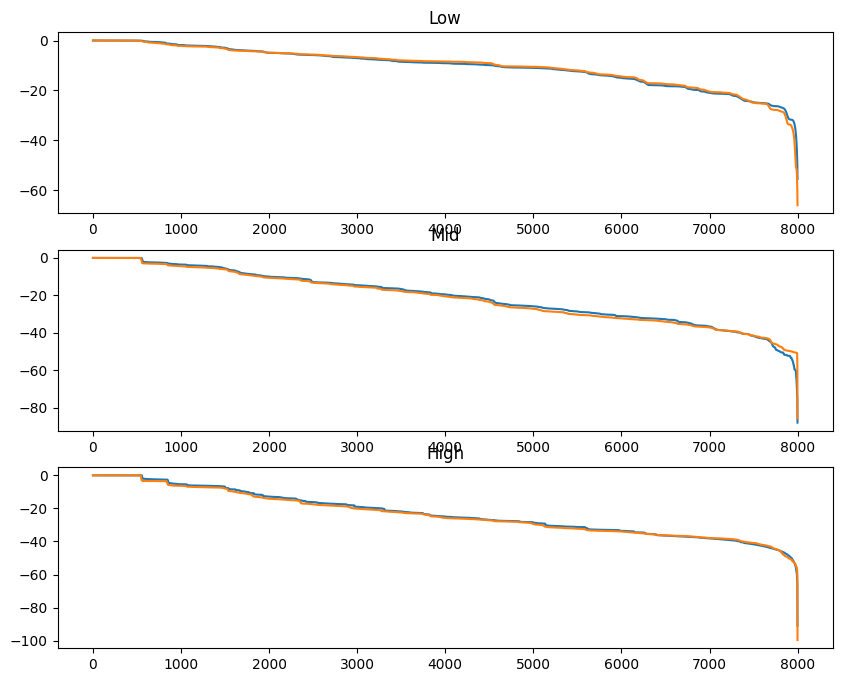

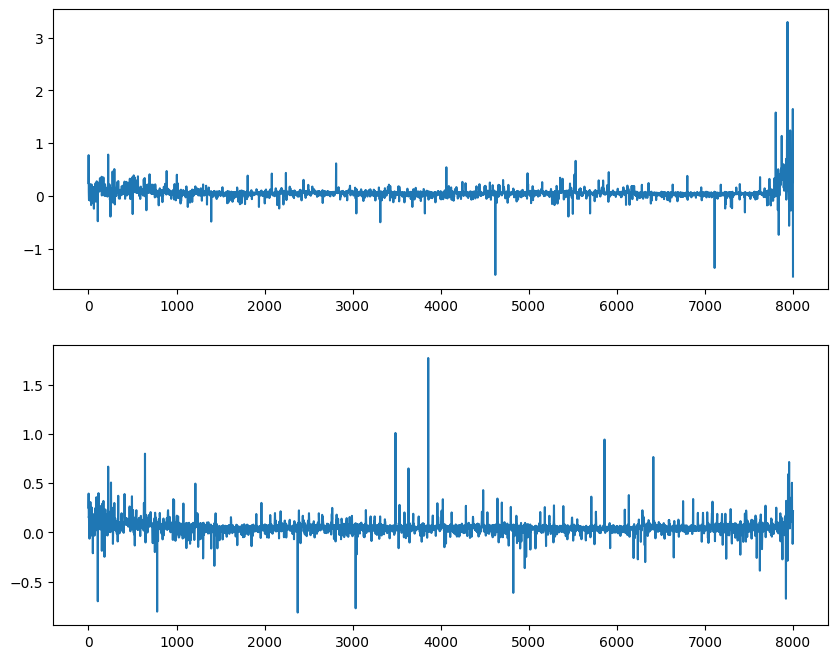

In [9]:
gt_wav = '/data/250010171/code/EigeNet_discriminant/data/debug/S005_R070_hybrid_IR_16000hz.wav'
pred_wav = '/data/250010171/code/EigeNet_discriminant/data/debug/S005_R070_hybrid_IR_16000hz_recon.wav'
gt_rir = librosa.load(gt_wav, sr=16000)[0][:8000]
pred_rir = librosa.load(pred_wav, sr=16000)[0][:8000]
results = analyze_banded_edc(gt_rir, pred_rir)
fig, axs = plt.subplots(3, 1, figsize=(10, 8))
for i, key in enumerate(results.keys()):
    axs[i].plot(results[key]['gt_db'])
    axs[i].plot(results[key]['pred_db'])
    axs[i].set_title(key)
plt.show()
plt.close()


freq_gt, gd_gt = extract_group_delay(gt_rir)
freq_pred, gd_pred = extract_group_delay(pred_rir)
fig, axs = plt.subplots(2, 1, figsize=(10, 8))
axs[0].plot(freq_gt, gd_gt)
axs[1].plot(freq_pred, gd_pred)
plt.show()
plt.close()




In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, resample

def gcc_phat(sig, refsig, fs=16000, interp=1):
    """
    计算两个信号之间的 GCC-PHAT 互相关
    interp: 插值倍数，用于提高时间分辨率
    """
    n = sig.shape[0] * interp
    # 频域变换
    SIG = np.fft.rfft(sig, n=n)
    REFSIG = np.fft.rfft(refsig, n=n)
    
    # 互功率谱密度
    R = SIG * np.conjugate(REFSIG)
    
    # PHAT 加权: 只保留相位信息
    # 添加 epsilon 防止除零
    eps = 1e-15
    phi = R / (np.abs(R) + eps)
    
    # 逆变换回到时域
    cc = np.fft.irfft(phi, n=n)
    
    # 将 0 延迟移到中间
    cc = np.concatenate((cc[-n//2:], cc[:n//2]))
    
    # 生成时间轴 (单位: ms)
    lags = np.arange(-n//2, n//2) * (1.0 / (fs * interp)) * 1000
    return cc, lags

def calculate_psr(cc, peak_width_ms=2, fs=16000):
    """
    计算峰值侧瓣比 (Peak-to-Sidelobe Ratio)
    peak_width_ms: 定义主峰的宽度（在此范围外的视为侧瓣）
    """
    peak_idx = np.argmax(np.abs(cc))
    peak_val = np.abs(cc[peak_idx])
    
    # 定义主峰区域
    half_width = int((peak_width_ms / 1000) * fs / 2)
    start = max(0, peak_idx - half_width)
    end = min(len(cc), peak_idx + half_width)
    
    # 提取侧瓣（排除主峰区域）
    sidelobes = np.concatenate((cc[:start], cc[end:]))
    
    # PSR 定义: 峰值 / 侧瓣的标准差
    psr = peak_val / (np.std(sidelobes) + 1e-10)
    return psr, peak_idx

def analyze_multiband_gcc_phat(rir_gt, rir_pred, fs=16000):
    bands = {
        "Full Band": (20, 7999),
        "Low (0-500Hz)": (20, 500),
        "Mid (500-2kHz)": (500, 2000),
        "High (2k-8kHz)": (2000, 7999)
    }
    
    plt.figure(figsize=(15, 10))
    results = {}

    for i, (name, (low, high)) in enumerate(bands.items()):
        # 1. 带通滤波
        b, a = butter(4, [low, high], btype='bandpass', fs=fs)
        f_gt = filtfilt(b, a, rir_gt)
        f_pred = filtfilt(b, a, rir_pred)
        
        # 2. 计算 GCC-PHAT (使用 4 倍插值以获得更平滑的峰值)
        cc, lags = gcc_phat(f_pred, f_gt, fs=fs, interp=4)
        
        # 3. 计算 PSR 指标
        psr, p_idx = calculate_psr(cc, fs=fs*4) # 注意插值后的采样率
        results[name] = psr
        
        # 4. 绘图
        plt.subplot(2, 2, i+1)
        plt.plot(lags, cc, label=f'PSR: {psr:.2f}')
        plt.axvline(x=0, color='r', linestyle='--', alpha=0.5, label='Zero Lag')
        plt.title(f"GCC-PHAT: {name}")
        plt.xlabel("Time Lag (ms)")
        plt.ylabel("Correlation Amplitude")
        plt.xlim([-20, 20]) # 重点观察 0 延迟附近的峰值
        plt.grid(True, alpha=0.3)
        plt.legend()

    plt.tight_layout()
    plt.show()
    
    return results

# 使用示例 (假设你已有 rir_gt 和 rir_pred)
# stats = analyze_multiband_gcc_phat(rir_gt, rir_pred, fs=16000)

/root/miniconda3/envs/eigenet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


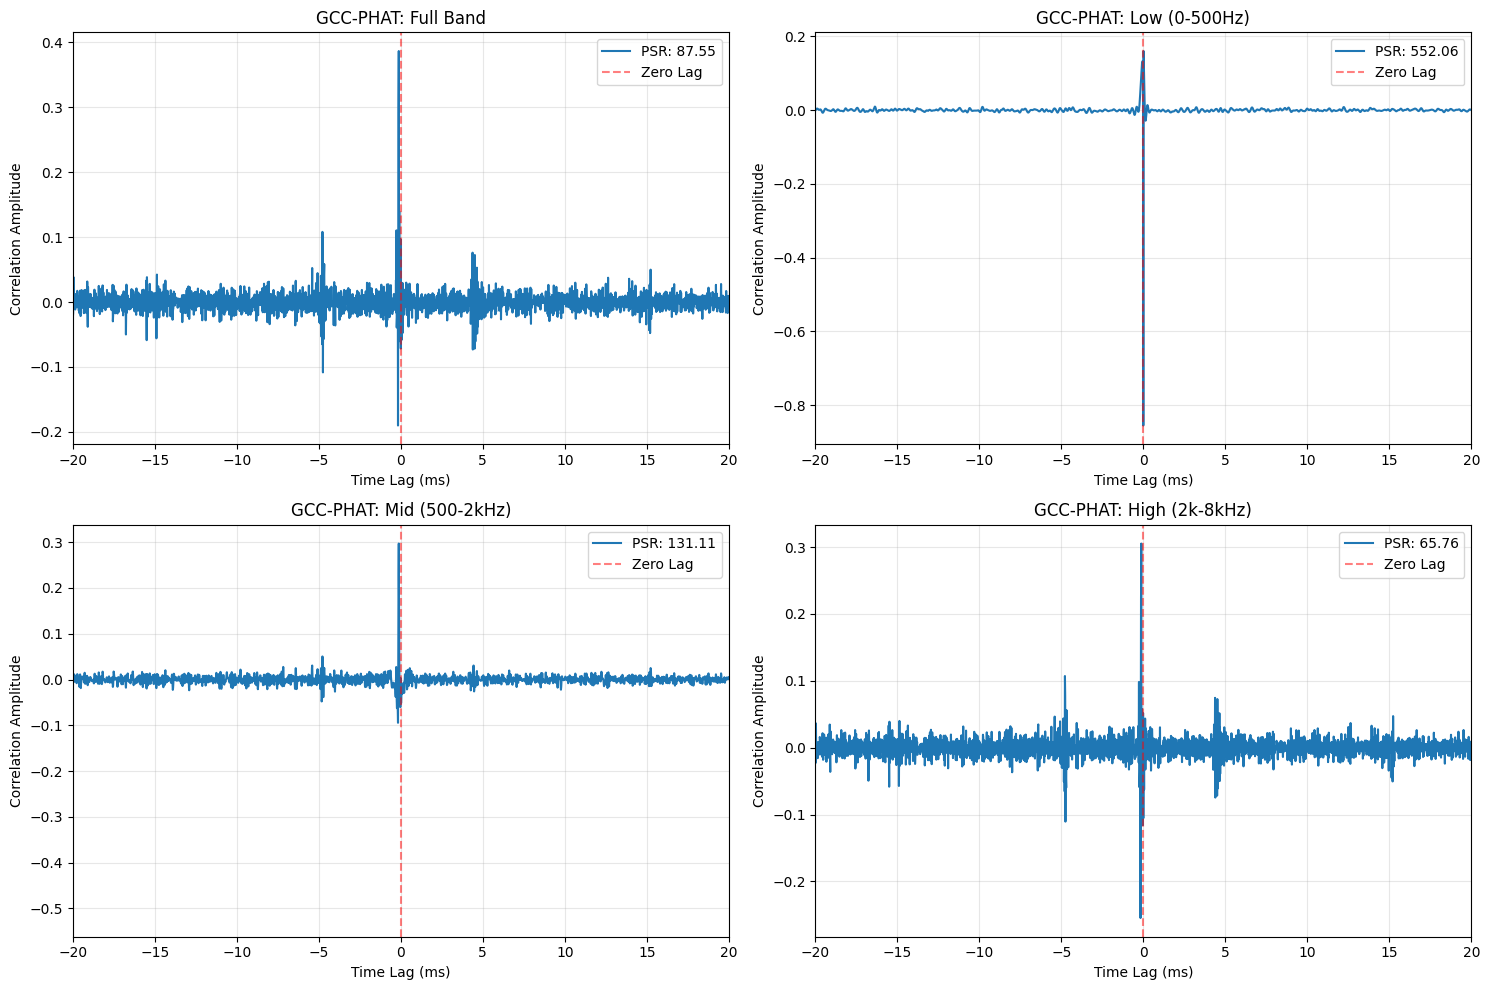

In [3]:
gt_wav = '/data/250010171/code/EigeNet_discriminant/data/debug/S005_R070_hybrid_IR_16000hz.wav'
pred_wav = '/data/250010171/code/EigeNet_discriminant/data/debug/S005_R070_hybrid_IR_16000hz_recon.wav'
gt_rir = librosa.load(gt_wav, sr=16000)[0][:8000]
pred_rir = librosa.load(pred_wav, sr=16000)[0][:8000]
stats = analyze_multiband_gcc_phat(gt_rir, pred_rir, fs=16000)

split haa for finetuning

In [ ]:
random.seed(114)
haa_new_jsonl = '/data/250010171/code/EigeNet_discriminant/data/haa_finetune.jsonl'
haa_train_jsonl = '/data/250010171/code/EigeNet_discriminant/data/haa_finetune_train.jsonl'
haa_test_jsonl = '/data/250010171/code/EigeNet_discriminant/data/haa_finetune_test.jsonl'

haa_df = pd.read_json(haa_new_jsonl, lines=True)
train_df = haa_df[haa_df['split'] == 'train']
test_df = haa_df[haa_df['split'] == 'test']
train_df.to_json(haa_train_jsonl, orient='records', lines=True)
test_df.to_json(haa_test_jsonl, orient='records', lines=True)


可视化2d深度图

In [2]:
def visualize_depth_2d(depth_path):
    # 1. 加载深度图
    depth_map = np.load(depth_path)
    
    # 2. 创建画布并获取 figure 和 axes 对象
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # 3. 在对应的 ax 上绘制热力图，并将其赋值给 im 以便后续生成颜色条
    im = ax.imshow(depth_map, cmap='plasma') 

    ax.axis('off') # 关闭坐标轴刻度
    
    # 5. 确保在返回前关闭绘图窗口的自动弹出（如果你在脚本中批量跑）
    # plt.close(fig) # 如果你只想保存不想在IDE里弹出来，可以取消注释这行
    
    # 6. 返回 fig 对象
    return fig

创建可视化所需数据的json

In [24]:

root = '/data/share/amphion/data/noise-and-rirs/AcousticRooms/'

jsonl = '/data/250010171/code/EigeNet_discriminant/data/AcousticRooms_test_unseen.jsonl'
df = pd.read_json(jsonl, lines=True)
#idx = random.randint(0, len(df)-1)
tgt_depth_path = '/data/share/amphion/data/noise-and-rirs/AcousticRooms/depth_map/Cafe/Cafe_idx_1/3.npy'
chosen_df = df[df['depth_path'] == tgt_depth_path]
idx = random.randint(0, len(chosen_df)-1)
data = chosen_df.iloc[idx]
scene_name = data['scene_name']
scene_id = data['scene_id']
src_loc = data['src_loc']
rec_loc = data['rec_loc']
other_src_idx_list = data['other_src_idx_list']
output_data = {
    "tgt_depth_path": os.path.relpath(data['depth_path'], root),
    "tgt_rir_path": os.path.relpath(data['rir_path'], root),
    "tgt_src_loc": src_loc,
    "tgt_rec_loc": rec_loc,
    "references": []  # 用来存放所有的 other src 信息
}

# 2. 循环处理 reference 并保存到字典
ref_tgt_dir = '/data/250010171/code/EigeNet_discriminant/data/visualization/'
os.makedirs(ref_tgt_dir, exist_ok=True) # 确保目录存在

for other_src_idx in other_src_idx_list:
    other_src_data = chosen_df[chosen_df['src_idx'] == other_src_idx].iloc[0]
    
    # 提取信息
    ref_info = {
        "src_idx": int(other_src_idx), # 确保是可序列化的 int
        "src_loc": other_src_data['src_loc'],
        "rir_path": os.path.relpath(other_src_data['rir_path'], root),
    }
    output_data["references"].append(ref_info)

# 3. 保存为 JSON 文件
json_output_path = os.path.join(os.path.dirname(ref_tgt_dir), 'visualization_data1.json')
with open(json_output_path, 'w', encoding='utf-8') as f:
    # indent=4 让生成的 json 文件有缩进，方便人类阅读
    json.dump(output_data, f, indent=4, ensure_ascii=False)

print(f"数据已成功保存至: {json_output_path}")


数据已成功保存至: /data/250010171/code/EigeNet_discriminant/data/visualization/visualization_data1.json


展示depth 2d

/data/250010171/code/EigeNet_discriminant/data/haa_depthmap/classroomBase.npy


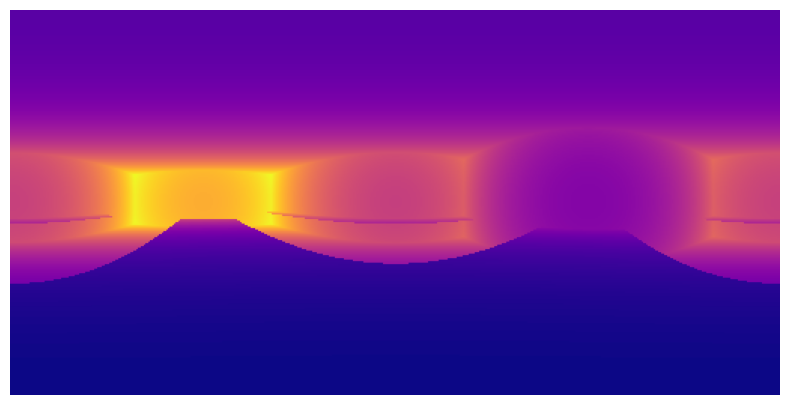

In [3]:
jsonl = '/data/250010171/code/EigeNet_discriminant/data/AcousticRooms_test_unseen.jsonl'
df = pd.read_json(jsonl, lines=True)
idx = random.randint(0, len(df)-1)
data = df.iloc[idx]
depth_path = '/data/250010171/code/EigeNet_discriminant/data/haa_depthmap/classroomBase.npy'
#depth_path = data['depth_path']
#scene_name = data['scene_name']
print(depth_path)
#print(scene_name)
fig = visualize_depth_2d(depth_path)
#save_path = f'/data/250010171/code/EigeNet_discriminant/visualization/out/{scene_name}_depth_map.pdf'
#fig.savefig(save_path)

plot_waveform

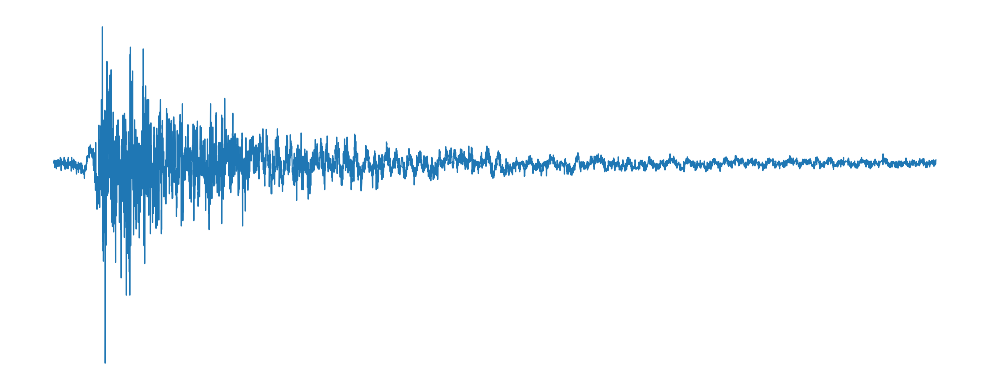

In [49]:
def plot_waveform(waveform, sr, title="Waveform"):
    """
    输入单通道音频，返回包含波形图的 fig 对象
    Args:
        waveform (Tensor or ndarray): 形状为 (1, T) 或 (T,)
        sr (int): 采样率
    """
    # 确保是 Numpy 且形状正确
    if isinstance(waveform, torch.Tensor):
        waveform = waveform.cpu().numpy()
    if waveform.ndim == 1:
        waveform = waveform[None, :]

    num_channels, num_frames = waveform.shape
    time_axis = np.arange(0, num_frames) / sr

    # 创建 fig 和 ax
    fig, ax = plt.subplots(figsize=(10, 4))
    
    # 绘制波形 (取第一通道)
    ax.plot(time_axis, waveform[0], linewidth=0.8, color='#1f77b4')
    ax.axis('off')
    plt.tight_layout()
    return fig

# --- 使用示例 ---
# fig_wf = plot_waveform(gt_tgt_ir, sample_rate, title="GT Waveform")
# fig_wf.savefig("waveform.pdf")
gt_rir_path = '/data/250010171/code/EigeNet_discriminant/visualization/out/gt_ir.wav'
pred_rir_path = '/data/250010171/code/EigeNet_discriminant/visualization/out/pred_ir_xrir.wav'
sample_rate = 16000
gt_rir = librosa.load(gt_rir_path, sr=16000)[0]
pred_rir = librosa.load(pred_rir_path, sr=16000)[0]
min_length = min(len(gt_rir), len(pred_rir))
#gt_tgt_ir = gt_rir[None, :min_length]
pred_tgt_ir = pred_rir[None, :min_length]

#gt_waveform_fig = plot_waveform(gt_tgt_ir, sample_rate, title="GT")
pred_waveform_fig = plot_waveform(pred_tgt_ir, sample_rate, title="Pred")

#gt_save_path = '/data/250010171/code/EigeNet_discriminant/visualization/out/gt_waveform.pdf'
pred_save_path = '/data/250010171/code/EigeNet_discriminant/visualization/out/pred_waveform_xrir.pdf'
#gt_waveform_fig.savefig(gt_save_path)
pred_waveform_fig.savefig(pred_save_path)


plot_stft

torch.Size([1, 60, 257])


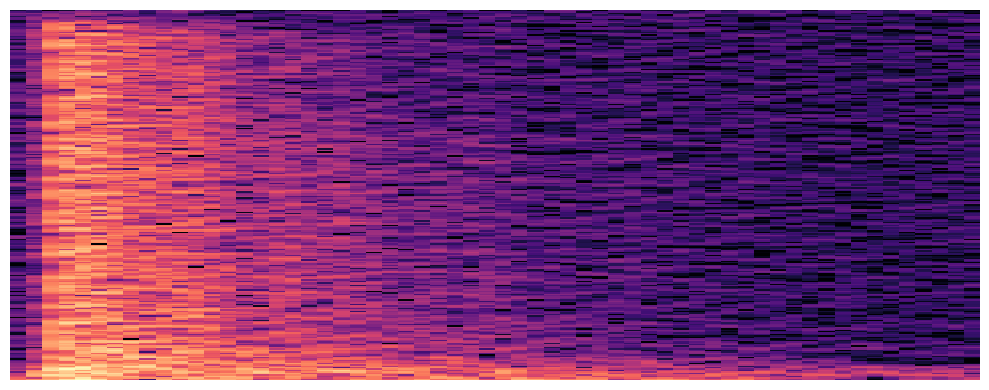

In [50]:
def stft(x, fft_size, hop_size, win_length, window):
    """Perform STFT and convert to magnitude spectrogram.
    Args:
        x (Tensor): Input signal tensor (B, T).
        fft_size (int): FFT size.
        hop_size (int): Hop size.
        win_length (int): Window length.
        window (Tensor): Window function type.
    Returns:
        Tensor: Magnitude spectrogram (B, #frames, fft_size // 2 + 1).
    """
    window = window.to(x.device)
    x_stft = torch.stft(x, fft_size, hop_size, win_length, window, return_complex=True, pad_mode='constant')
    real = torch.real(x_stft)
    imag = torch.imag(x_stft)

    # NOTE(kan-bayashi): clamp is needed to avoid nan or inf
    return torch.sqrt(torch.clamp(real ** 2 + imag ** 2, min=1e-7)).transpose(2, 1)


import librosa.display

def plot_stft(wav, sample_rate=16000, title="Spectrogram", fft_size=512, hop_size=128, win_length=512):
    """
    输入单个音频，计算并返回其 STFT 可视化的 fig 对象
    Args:
        wav (Tensor or ndarray): 输入音频，形状支持 (T,) 或 (1, T)
        sample_rate (int): 采样率
    Returns:
        fig: Matplotlib figure 对象
    """
    # 1. 数据预处理：确保是 (1, T) 的 Tensor
    if isinstance(wav, np.ndarray):
        wav = torch.from_numpy(wav).float()
    if wav.ndim == 1:
        wav = wav.unsqueeze(0)
    
    # 2. 计算 STFT (使用你之前定义的 stft 函数)
    window = torch.hann_window(win_length).to(wav.device)
    with torch.no_grad():
        # 输出形状为 (1, frames, freq)
        spec = stft(wav, fft_size, hop_size, win_length, window)
        spec = spec[:, 1:-2]
        print(spec.shape)
    
    # 3. 转换为 dB 缩放的 Numpy 数组 (freq, frames)
    # 绘图习惯是将频率放在 y 轴，时间放在 x 轴
    spec_np = spec[0].cpu().numpy().T 
    spec_db = librosa.amplitude_to_db(spec_np, ref=np.max)

    # 4. 创建绘图
    fig, ax = plt.subplots(figsize=(10, 4))
    img = librosa.display.specshow(
        spec_db, 
        sr=sample_rate, 
        hop_length=hop_size, 
        x_axis='time', 
        y_axis='linear', 
        ax=ax, 
        cmap='magma'
    )
    ax.axis('off')

    plt.tight_layout()
    
    return fig

gt_rir_path = '/data/250010171/code/EigeNet_discriminant/visualization/out/gt_ir.wav'
pred_rir_path = '/data/250010171/code/EigeNet_discriminant/visualization/out/pred_ir_xrir.wav'
sample_rate = 16000
gt_rir = librosa.load(gt_rir_path, sr=16000)[0]
pred_rir = librosa.load(pred_rir_path, sr=16000)[0]
min_length = min(len(gt_rir), len(pred_rir))
gt_tgt_ir = gt_rir[None, :min_length]
pred_tgt_ir = pred_rir[None, :min_length]

#gt_stft_fig = plot_stft(gt_tgt_ir, fft_size=512, hop_size=128, win_length=512, sample_rate=16000)
pred_stft_fig = plot_stft(pred_tgt_ir, fft_size=512, hop_size=128, win_length=512, sample_rate=16000)

#gt_save_path = '/data/250010171/code/EigeNet_discriminant/visualization/out/gt_stft.pdf'
pred_save_path = '/data/250010171/code/EigeNet_discriminant/visualization/out/pred_stft_xrir.pdf'
#gt_stft_fig.savefig(gt_save_path)
pred_stft_fig.savefig(pred_save_path)


In [42]:
spec = stft(torch.from_numpy(pred_tgt_ir), fft_size=512, hop_size=128, win_length=512, window=torch.hann_window(512))
print(pred_tgt_ir.shape)
print(spec.shape)

(1, 7992)
torch.Size([1, 63, 257])
